# Figures S5, S6, and S7


In [1]:
import sys
sys.path.insert(0, '../') # Trick to import code from parent folder
from pathlib import Path

import cmip6_archive as ca
import numpy as np
import xesmf as xe
import xarray as xr

import matplotlib.pyplot as plt
from cartopy import crs as ccrs
import colormaps as cmaps
from plot_utils import plot_panel

# Ignore repeated warnings after the first occurrence
import warnings
warnings.filterwarnings("once")

# Computations common to all figures

In [2]:
def regrid(ds_in, regrid_to, method="conservative", skipna=False):
    """Convenience function for one-time regridding. Regrids data in `ds_in` to the grid used in `regrid_to`."""
    regridder = xe.Regridder(ds_in, regrid_to, method=method, periodic=True) # When dealing with global grids, we need to set periodic=True, otherwise data along the meridian line will be missing.
    ds_out = regridder(ds_in, skipna=skipna)
    return ds_out

# Common 1º x 1º grid to compute the MME later
common_grid = xr.Dataset({
        "lat": ("lat", np.arange(-89.5, 90.0, 1.0)),
        "lon": ("lon", np.arange(0.5, 360.0, 1.0)),
})

BASELINE_YEARS = slice(1981, 2000)   # matches the 90th-percentile reference period
FUTURE_YEARS = slice(2071, 2100)

In [3]:
SSP_EXPERIMENTS = [exp for exp in ca.EXPERIMENTS if exp != "historical"]  # ssp126, ssp245, ssp370, ssp585

# Regridding weights are cached on disk, one file per model
WEIGHTS_DIR = Path("./.regrid_weights")
WEIGHTS_DIR.mkdir(exist_ok=True)

def get_regridder(model, grid_in, regrid_to, method="conservative"):
    """Load a model's regridder weights from disk if cached, otherwise build and cache them.
    Weights depend only on the model's grid and land mask, so they are valid for all experiments."""
    weights_path = WEIGHTS_DIR / f"{model}_to_1deg_{method}.nc"
    if weights_path.exists():
        print(f"[{model}] Loading regridder weights from {weights_path}")
        return xe.Regridder(grid_in, regrid_to, method=method, periodic=True, weights=str(weights_path))

    print(f"[{model}] Building regridder (this is the slow step)...")
    regridder = xe.Regridder(grid_in, regrid_to, method=method, periodic=True)
    regridder.to_netcdf(str(weights_path))
    return regridder

def calculate_tw_metrics_anomalies(ref_grid_ds, exps = SSP_EXPERIMENTS, anom_type = "relative", models = ca.MODELS):
    # This function is adapted from https://projectpythia.org/cmip6-cookbook/notebooks/example-workflows/xesmf-ohu/
    # Credit goes to R. Abernathey, H. Drake, R. R. Ford, M. Grover, and Project Pythia contributors (2026)

    print(f"Calculating {anom_type} anomalies for {len(models)} models x {len(exps)} experiments...")

    ds_regrid_dict = {exp: {} for exp in exps}
    success_count = 0
    model_count = 0

    for model in models:
        # Per-model setup, done once and reused for every experiment:
        try:
            # Load historical baseline, land mask and regridder
            ds_historical = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp='historical').sel(year=BASELINE_YEARS)
            baseline = ds_historical.mean(dim='year').load()

            land_area_fraction = ca.LAND_MASKS_ARCHIVE.open(model=model, exp='piControl')['sftlf']
            mask = (land_area_fraction >= 5).values

            # The mask is stored in the grid used to build the regridder, so conservative
            # regridding ignores ocean cells (see https://pangeo-xesmf.readthedocs.io/en/latest/notebooks/Masking.html#)
            grid_in = baseline.assign(mask=(('lat', 'lon'), mask))
            regridder = get_regridder(model, grid_in, ref_grid_ds)

            if anom_type == "relative":
                baseline_denom = baseline.where(baseline != 0) # Avoids inf where baseline is 0
        except Exception as e:
            print('Failed to set up '+model+': '+str(e))
            model_count += len(exps)
            continue

        for exp in exps:
            try:
                # 1. Find anomaly with respect to historical baseline for all thirstwave metrics (intensity, frequency, etc.)
                ds_exp = ca.THIRSTWAVE_METRICS_GS_ARCHIVE.open(model=model, exp=exp).sel(year=FUTURE_YEARS)
                end_of_century = ds_exp.mean(dim='year')

                if anom_type == "absolute":
                    anomaly = (end_of_century - baseline) # Absolute change
                elif anom_type == "relative":
                    anomaly = (end_of_century - baseline) / baseline_denom # Relative change (%)
                else:
                    raise ValueError("anom_type should be either 'absolute' or 'relative'")

                # 2. Mask out grid cells with < 5% land and regrid to the common grid
                anomaly = anomaly.where(mask)
                anomaly_regridded = regridder(anomaly, skipna=True)
                if 'type' in anomaly_regridded.coords:
                    anomaly_regridded = anomaly_regridded.drop_vars("type")

            except Exception as e:
                print(f'[{exp}] Failed to regrid '+model+': '+str(e))

            else:
                # 3. Add to dict
                ds_regrid_dict[exp][model] = anomaly_regridded
                print(f'[{exp}] '+model+' regridded and added to dictionary')
                success_count += 1
            finally:
                model_count += 1

    print('-'*40+'\n| '+str(success_count)+'/'+str(model_count)+' models successfully regridded! |\n'+'-'*40)

    # One Dataset per experiment, with all models stacked along 'model'
    ds_out_regrid = {}
    for exp in exps:
        if not ds_regrid_dict[exp]:
            print(f"[{exp}] No models regridded, skipping concatenation")
            continue
        ds = list(ds_regrid_dict[exp].values())
        coord = list(ds_regrid_dict[exp].keys())
        ds_out_regrid[exp] = xr.concat(objs=ds, dim=coord, coords='all').rename({'concat_dim':'model'})

    return ds_out_regrid

ds_out_regrid = calculate_tw_metrics_anomalies(common_grid, anom_type="relative")

Calculating relative anomalies for 8 models x 4 experiments...


<frozen importlib._bootstrap>:491: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


[IPSL-CM6A-LR] Loading regridder weights from .regrid_weights/IPSL-CM6A-LR_to_1deg_conservative.nc


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


[ssp126] IPSL-CM6A-LR regridded and added to dictionary
[ssp245] IPSL-CM6A-LR regridded and added to dictionary
[ssp370] IPSL-CM6A-LR regridded and added to dictionary
[ssp585] IPSL-CM6A-LR regridded and added to dictionary
[MIROC6] Loading regridder weights from .regrid_weights/MIROC6_to_1deg_conservative.nc
[ssp126] MIROC6 regridded and added to dictionary
[ssp245] MIROC6 regridded and added to dictionary
[ssp370] MIROC6 regridded and added to dictionary
[ssp585] MIROC6 regridded and added to dictionary
[MRI-ESM2-0] Loading regridder weights from .regrid_weights/MRI-ESM2-0_to_1deg_conservative.nc
[ssp126] MRI-ESM2-0 regridded and added to dictionary
[ssp245] MRI-ESM2-0 regridded and added to dictionary
[ssp370] MRI-ESM2-0 regridded and added to dictionary
[ssp585] MRI-ESM2-0 regridded and added to dictionary
[NorESM2-LM] Loading regridder weights from .regrid_weights/NorESM2-LM_to_1deg_conservative.nc


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


[ssp126] NorESM2-LM regridded and added to dictionary
[ssp245] NorESM2-LM regridded and added to dictionary
[ssp370] NorESM2-LM regridded and added to dictionary
[ssp585] NorESM2-LM regridded and added to dictionary
[NorESM2-MM] Loading regridder weights from .regrid_weights/NorESM2-MM_to_1deg_conservative.nc


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


[ssp126] NorESM2-MM regridded and added to dictionary
[ssp245] NorESM2-MM regridded and added to dictionary
[ssp370] NorESM2-MM regridded and added to dictionary
[ssp585] NorESM2-MM regridded and added to dictionary
[MPI-ESM1-2-HR] Loading regridder weights from .regrid_weights/MPI-ESM1-2-HR_to_1deg_conservative.nc
[ssp126] MPI-ESM1-2-HR regridded and added to dictionary
[ssp245] MPI-ESM1-2-HR regridded and added to dictionary
[ssp370] MPI-ESM1-2-HR regridded and added to dictionary
[ssp585] MPI-ESM1-2-HR regridded and added to dictionary
[MPI-ESM1-2-LR] Loading regridder weights from .regrid_weights/MPI-ESM1-2-LR_to_1deg_conservative.nc
[ssp126] MPI-ESM1-2-LR regridded and added to dictionary
[ssp245] MPI-ESM1-2-LR regridded and added to dictionary
[ssp370] MPI-ESM1-2-LR regridded and added to dictionary
[ssp585] MPI-ESM1-2-LR regridded and added to dictionary
[UKESM1-0-LL] Loading regridder weights from .regrid_weights/UKESM1-0-LL_to_1deg_conservative.nc
[ssp126] UKESM1-0-LL regridde

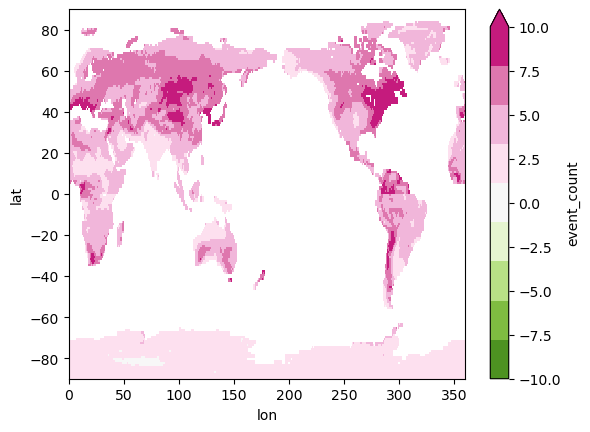

In [4]:
# Take mean across models
mmes = {}
for exp in SSP_EXPERIMENTS:
    mmes[exp] = ds_out_regrid[exp].mean(dim='model', skipna=False)

mmes['ssp585']['event_count'].plot(cmap=cmaps.piyg_r, vmin=-10, vmax=10)

# Figure S5
### Projected changes in thirstwave frequency under four SSPs.
End-of-century (2071–2100) percentage changes relative to the historical baseline (1981–2000) under SSP1-2.6, SSP2-4.5, SSP3-7.0, and SSP5-8.5. Maps show the multi-model mean

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp

  ✓ png/FigureS5.png
  ✓ pdf/FigureS5.pdf


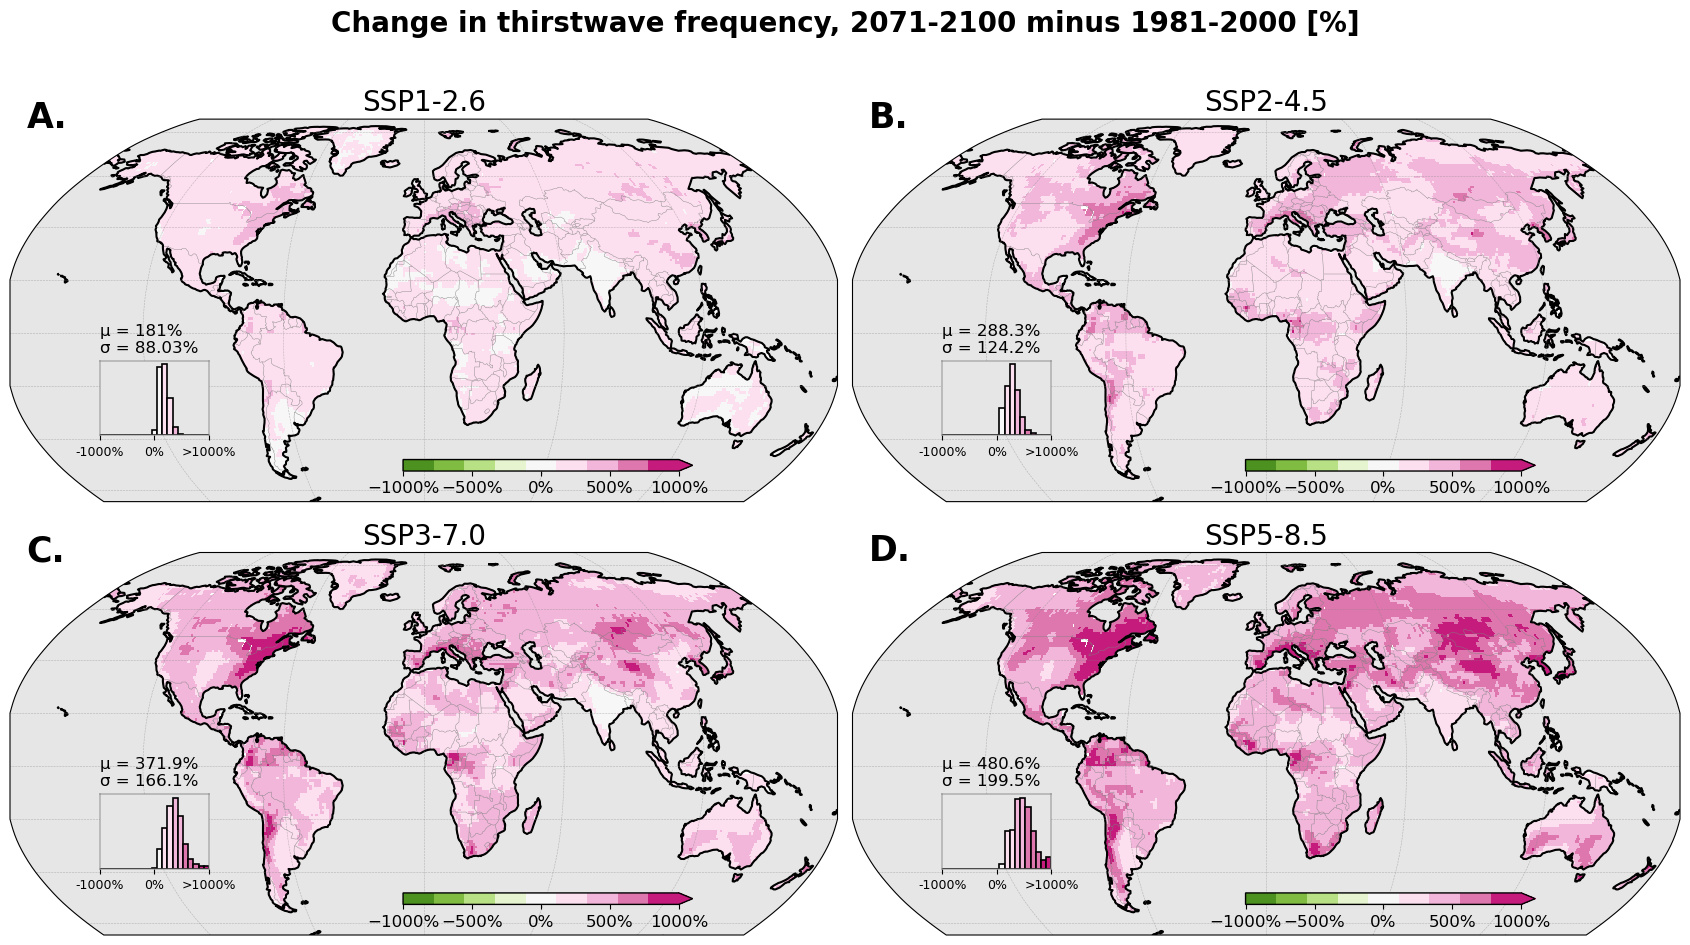

In [5]:
from plot_utils import plot_panel

# Multiply by 100 to put relative anomaly into % form (0.1 -> 10%)
freq_mmes = {exp: mmes[exp]['event_count']*100 for exp in SSP_EXPERIMENTS}

#  2x2 subplot
fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 10),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

VMIN = -1000
VMAX = 1000
CMAP = cmaps.piyg_r

# panel A. SSP1-2.6
plot_panel(
    axes[0],
    freq_mmes['ssp126'],
    r"SSP1-2.6",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="A.",
    anom_type="relative",
)

# panel B. SSP2-4.5
plot_panel(
    axes[1],
    freq_mmes['ssp245'],
    r"SSP2-4.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="B.",
    anom_type="relative",
)

# panel C. SSP3-7.0
plot_panel(
    axes[2],
    freq_mmes['ssp370'],
    r"SSP3-7.0",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="C.",
    anom_type="relative",
)

# panel C. SSP5-8.5
plot_panel(
    axes[3],
    freq_mmes['ssp585'],
    r"SSP5-8.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="D.",
    anom_type="relative",
)

suptitle = r"Change in thirstwave frequency, 2071-2100 minus 1981-2000 [%]" + "\n"
fig.suptitle(suptitle, fontsize=20, fontweight="bold")
plt.tight_layout()

# Save as png and pdf
for ext in ["png", "pdf"]:
        filename = f"{ext}/FigureS5.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()

# Figure S6
## Projected changes in thirstwave intensity under four SSPs
End-of-century (2071–2100) percentage changes relative to the historical baseline (1981–2000) under SSP1-2.6, SSP2-4.5, SSP3-7.0, and SSP5-8.5. Maps show the multi-model mean.

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp

  ✓ png/FigureS6.png
  ✓ pdf/FigureS6.pdf


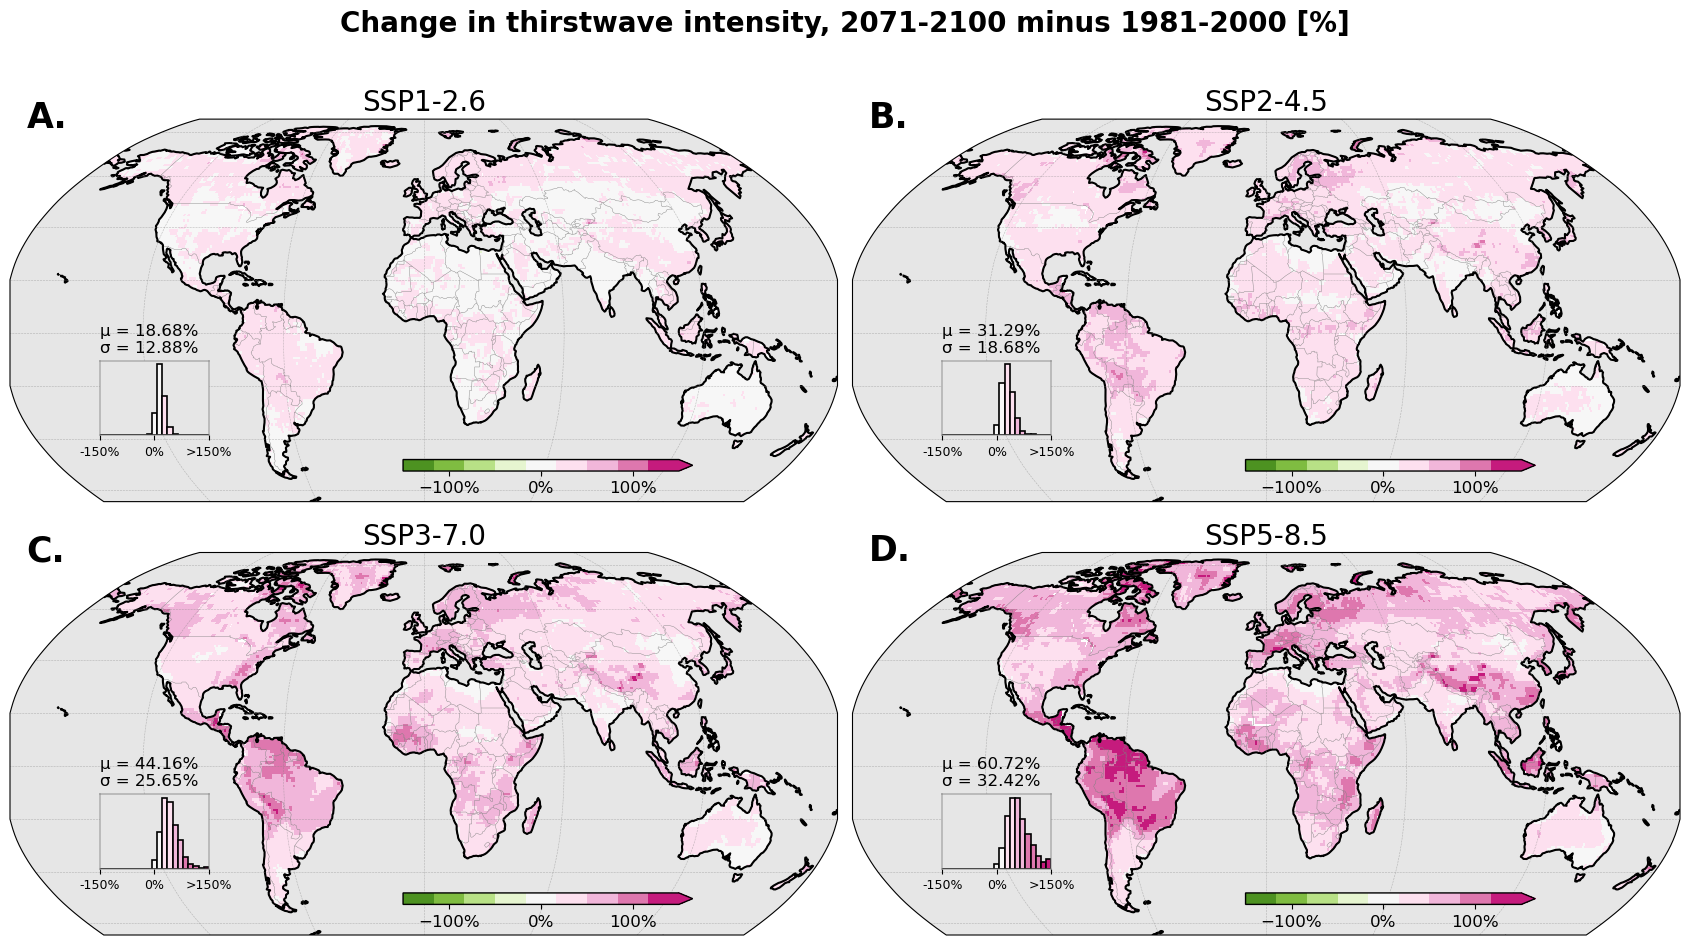

In [7]:
from plot_utils import plot_panel

# Multiply by 100 to put relative anomaly into % form (0.1 -> 10%)
intensity_mmes = {exp: mmes[exp]['intensity']*100 for exp in SSP_EXPERIMENTS}

#  2x2 subplot
fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 10),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

VMIN = -150
VMAX = 150
CMAP = cmaps.piyg_r

# panel A. SSP1-2.6
plot_panel(
    axes[0],
    intensity_mmes['ssp126'],
    r"SSP1-2.6",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="A.",
    anom_type="relative",
)

# panel B. SSP2-4.5
plot_panel(
    axes[1],
    intensity_mmes['ssp245'],
    r"SSP2-4.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="B.",
    anom_type="relative",
)

# panel C. SSP3-7.0
plot_panel(
    axes[2],
    intensity_mmes['ssp370'],
    r"SSP3-7.0",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="C.",
    anom_type="relative",
)

# panel C. SSP5-8.5
plot_panel(
    axes[3],
    intensity_mmes['ssp585'],
    r"SSP5-8.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="D.",
    anom_type="relative",
)

suptitle = r"Change in thirstwave intensity, 2071-2100 minus 1981-2000 [%]" + "\n"
fig.suptitle(suptitle, fontsize=20, fontweight="bold")
plt.tight_layout()

# Save as png and pdf
for ext in ["png", "pdf"]:
        filename = f"{ext}/FigureS6.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()

# Figure S7
## Projected changes in thirstwave duration under four SSPs.
End-of-century (2071–2100) percentage changes relative to the historical baseline (1981–2000) under SSP1-2.6, SSP2-4.5, SSP3-7.0, and SSP5-8.5. Maps show the multi-model mean.

/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp

  ✓ png/FigureS7.png
  ✓ pdf/FigureS7.pdf


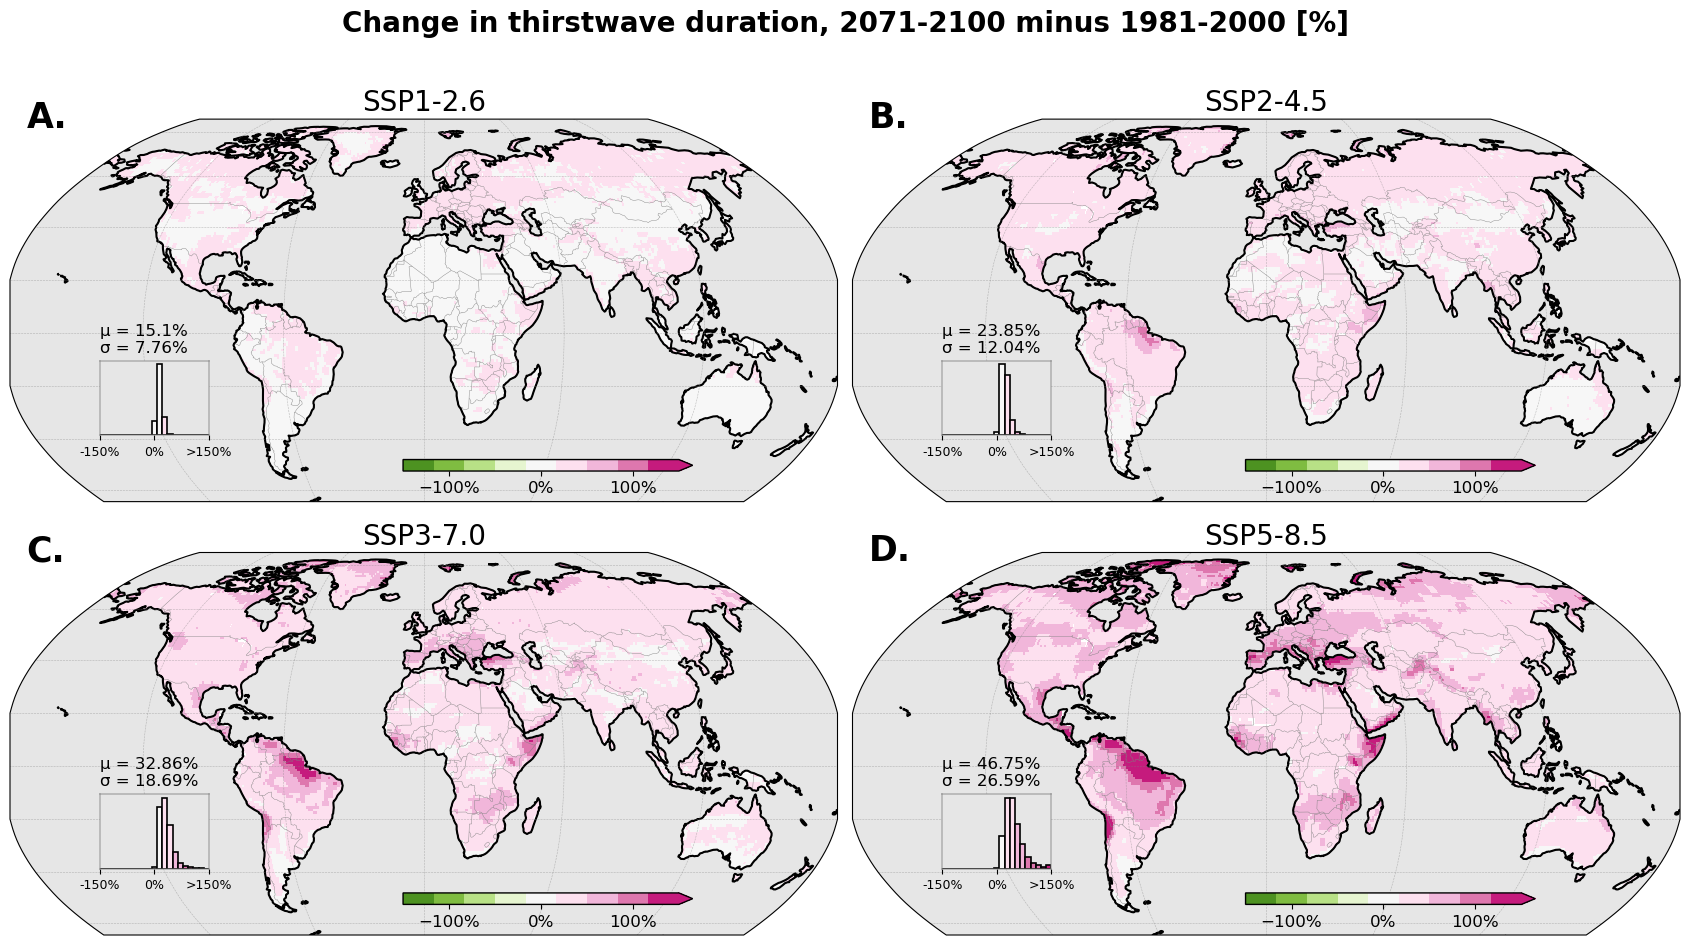

In [10]:
from plot_utils import plot_panel

# Multiply by 100 to put relative anomaly into % form (0.1 -> 10%)
duration_mmes = {exp: mmes[exp]['mean_duration']*100 for exp in SSP_EXPERIMENTS}

#  2x2 subplot
fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 10),
    subplot_kw={"projection": ccrs.Robinson()}
)

axes = axes.flatten()

VMIN = -150
VMAX = 150
CMAP = cmaps.piyg_r

# panel A. SSP1-2.6
plot_panel(
    axes[0],
    duration_mmes['ssp126'],
    r"SSP1-2.6",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="A.",
    anom_type="relative",
)

# panel B. SSP2-4.5
plot_panel(
    axes[1],
    duration_mmes['ssp245'],
    r"SSP2-4.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="B.",
    anom_type="relative",
)

# panel C. SSP3-7.0
plot_panel(
    axes[2],
    duration_mmes['ssp370'],
    r"SSP3-7.0",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="C.",
    anom_type="relative",
)

# panel C. SSP5-8.5
plot_panel(
    axes[3],
    duration_mmes['ssp585'],
    r"SSP5-8.5",
    vmin=VMIN,
    vmax=VMAX,
    cmap=CMAP,
    extend="max", 
    label="D.",
    anom_type="relative",
)

suptitle = r"Change in thirstwave duration, 2071-2100 minus 1981-2000 [%]" + "\n"
fig.suptitle(suptitle, fontsize=20, fontweight="bold")
plt.tight_layout()

# Save as png and pdf
for ext in ["png", "pdf"]:
        filename = f"{ext}/FigureS7.{ext}"
        fig.savefig(filename, dpi=500, bbox_inches="tight", pad_inches=0.3)
        print(f"  ✓ {filename}")

plt.show()